In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from skimage import color, transform
import seaborn as sns


In [2]:
# Function to download and preprocess the image
def preprocess_image(url):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize((100, 100))  # Resize the image for consistency
        img = np.array(img)
        img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])  # Convert to grayscale
        return img.flatten()  # Flatten the image to a 1D array
    except Exception as e:
        print(f"Error processing image from URL: {url}. Skipping...")
        return None

In [3]:

# Sample URLs of flood and non-flood images
flood_urls = [
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152153/riograndedosul_oli_2023325_lrg.jpg',
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152295/ukflooding_oli2_20240104_lrg.jpg',
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152051/italyflooding_oil_2023307_lrg.jpg'
    # Add more flood image URLs here
]

non_flood_urls = [
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152153/riograndedosul_oli_2023309_lrg.jpg',
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152295/ukflooding_oli2_20220105_lrg.jpg',
    'https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152051/italyflooding_oil_2023275.jpg'
    # Add more non-flood image URLs here
]

In [4]:
# Combine known flood and non-flood data
X_known = np.array([preprocess_image(url) for url in flood_urls + non_flood_urls if preprocess_image(url) is not None])
y_known = np.array([1] * len(flood_urls) + [0] * len(non_flood_urls))

# Train a Random Forest classifier on the known dataset
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_known, y_known)

# Calculate overall accuracy for known data
known_accuracy = accuracy_score(y_known, clf.predict(X_known))
print("Accuracy :", known_accuracy)


Accuracy : 1.0


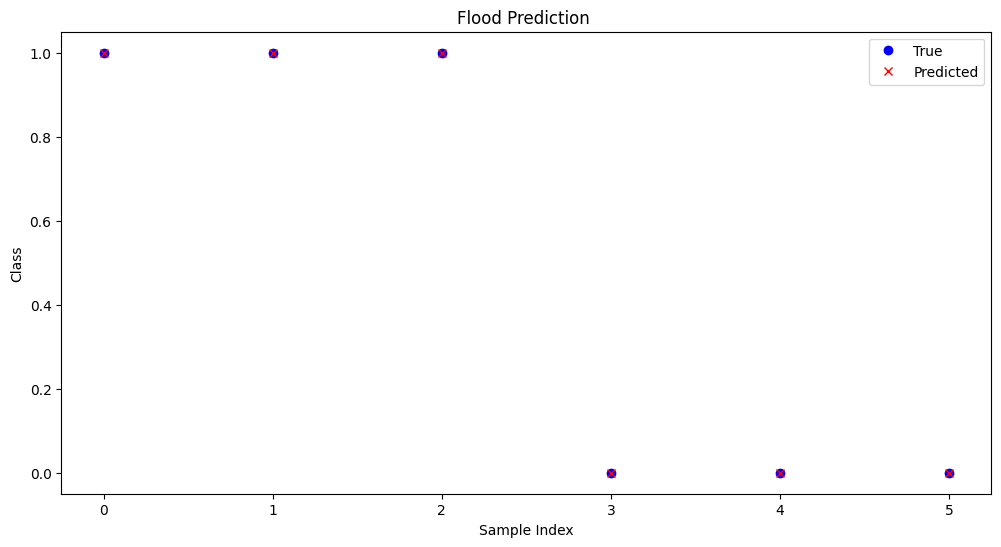

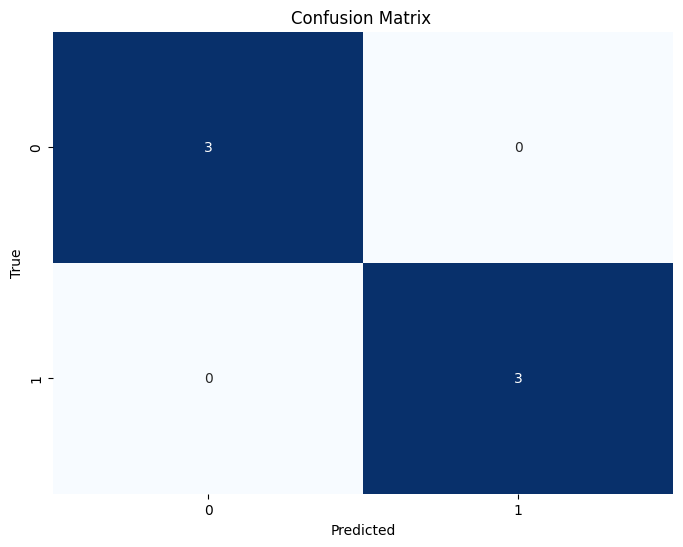

In [5]:
# Plot predictions for known data
plt.figure(figsize=(12, 6))
plt.plot(y_known, 'bo', label='True')
plt.plot(clf.predict(X_known), 'rx', label='Predicted')
plt.title('Flood Prediction ')
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.legend()
plt.show()

# Plot confusion matrix for known data
plt.figure(figsize=(8, 6))
cm_known = confusion_matrix(y_known, clf.predict(X_known))
sns.heatmap(cm_known, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix ')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [8]:
# Ask for URLs for prediction from the user
unknown_urls = []
num_unknown_images = int(input("Enter the number of unknown images: "))
for i in range(num_unknown_images):
    url = input(f"Enter URL for unknown image {i+1}: ")
    unknown_urls.append(url)

# Function to predict unknown images
def predict_unknown_images(urls):
    X_unknown = np.array([preprocess_image(url) for url in urls if preprocess_image(url) is not None])
    return clf.predict(X_unknown)

# Predictions for unknown images
y_unknown_pred = predict_unknown_images(unknown_urls)

# Display predictions for unknown images
print("Predictions for Unknown Images:")
for url, prediction in zip(unknown_urls, y_unknown_pred):
    print(f"Image URL: {url}, Predicted Class: {'Flood' if prediction == 1 else 'Non-Flood'}")

Enter the number of unknown images: 2
Enter URL for unknown image 1: https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152108/somaliafloodingzm_oli_2023255.jpg
Enter URL for unknown image 2: https://ichef.bbci.co.uk/news/800/cpsprodpb/5D27/production/_131974832_1_after_20231009_035134_07_24b6_3b_visual_clip.png
Predictions for Unknown Images:
Image URL: https://eoimages.gsfc.nasa.gov/images/imagerecords/152000/152108/somaliafloodingzm_oli_2023255.jpg, Predicted Class: Non-Flood
Image URL: https://ichef.bbci.co.uk/news/800/cpsprodpb/5D27/production/_131974832_1_after_20231009_035134_07_24b6_3b_visual_clip.png, Predicted Class: Flood
